# 0. Libs and Source directory

In [1]:
import os

notebook_path = os.path.abspath("")
source_folder = "src"
source_path = notebook_path[:notebook_path.find(source_folder) + len(source_folder)]

os.chdir(source_path)

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

from robyn.data.entities.mmmdata import MMMData
from robyn.data.entities.enums import AdstockType
from robyn.data.entities.holidays_data import HolidaysData
from robyn.data.entities.hyperparameters import Hyperparameters, ChannelHyperparameters
from robyn.modeling.entities.modelrun_trials_config import TrialsConfig
from robyn.modeling.model_executor import ModelExecutor
from robyn.modeling.entities.enums import NevergradAlgorithm, Models
from robyn.modeling.feature_engineering import FeatureEngineering

from robyn.modeling.clustering.clustering_config import ClusteringConfig, ClusterBy
from robyn.modeling.clustering.cluster_builder import ClusterBuilder
from robyn.data.entities.enums import DependentVarType
from robyn.modeling.pareto.pareto_utils import ParetoUtils

from robyn.allocator.entities.allocation_params import AllocatorParams
from robyn.allocator.allocator import BudgetAllocator
from robyn.allocator.constants import (
    SCENARIO_MAX_RESPONSE,
    CONSTRAINT_MODE_EQ,
    DATE_RANGE_ALL,
    DEFAULT_CONSTRAINT_MULTIPLIER,
    ALGO_SLSQP_AUGLAG,
)

from robyn.visualization.allocator_visualizer import AllocatorVisualizer

pio.renderers.default = "iframe"
pd.options.display.max_columns = None

# 1. Data

In [3]:
dt_prophet_holidays = pd.read_csv("data/03_primary/dt_prophet_holidays.csv")
dt_simulated_weekly = pd.read_csv("data/03_primary/dt_simulated_weekly.csv")

# 2. MMM Data
Define the model specification including dependent variables, independent variables, and analysis window.

### Key Components:
- `dep_var`: Your target metric (e.g., "revenue", "conversions")
- `dep_var_type`: Type of dependent variable ("revenue" for ROI or "conversion" for CPA)
- `date_var`: Column name containing dates
- `window_start/end`: Analysis time period

### Variable Types:
- `paid_media_spends`: Columns containing media spend data (e.g., TV, Facebook, Search)
- `paid_media_vars`: Media exposure metrics (impressions, clicks) in same order as spends
- `context_vars`: External factors (e.g., competitor activities, events, seasonality)
- `organic_vars`: Marketing activities without direct spend (e.g., email, social posts)

Example configuration:

In [4]:
mmm_data_spec = MMMData.MMMDataSpec(
    dep_var="revenue",
    dep_var_type="revenue",
    date_var="DATE",
    context_vars=["competitor_sales_B", "events"],
    factor_vars=["events"],
    paid_media_spends=["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"],
    paid_media_vars=["tv_S", "ooh_S", "print_S", "facebook_I", "search_clicks_P"],
    organic_vars=["newsletter"],
    window_start="2016-01-01",
    window_end="2018-12-31",
)

mmm_data = MMMData(data=dt_simulated_weekly, mmmdata_spec=mmm_data_spec)

# 3. Hyperparameters
Hyperparameters control how media effects are modeled.

Each channel requires three key parameters:

### Media Channel Parameters:
- `alphas`: Controls saturation curve shape [0.5, 3]
  - Lower values (0.5-1): More diminishing returns
  - Higher values (2-3): More S-shaped response
  
- `gammas`: Controls saturation curve inflection point [0.3, 1]
  - Lower values: Earlier diminishing returns
  - Higher values: Later diminishing returns

- `thetas`: Controls adstock decay rate [0, 0.8]
  - Lower values (0-0.2): Fast decay (e.g., Search, Social)
  - Medium values (0.1-0.4): Medium decay (e.g., Print, OOH)
  - Higher values (0.3-0.8): Slow decay (e.g., TV)

### Global Parameters:
- `adstock`: Type of carryover effect modeling
  - "geometric": Fixed decay rate
  - "weibull_cdf": Flexible decay with cumulative distribution
  - "weibull_pdf": Flexible decay with potential peak delay

- `lambda_`: Ridge regression regularization [0, 1]
- `train_size`: Proportion of data for training [0.5, 0.8]

In [5]:
hyperparameters = Hyperparameters(
    {
        "facebook_S": ChannelHyperparameters(
            alphas=[0.5, 3],
            gammas=[0.3, 1],
            thetas=[0, 0.3],
        ),
        "print_S": ChannelHyperparameters(
            alphas=[0.5, 3],
            gammas=[0.3, 1],
            thetas=[0.1, 0.4],
        ),
        "tv_S": ChannelHyperparameters(
            alphas=[0.5, 3],
            gammas=[0.3, 1],
            thetas=[0.3, 0.8],
        ),
        "search_S": ChannelHyperparameters(
            alphas=[0.5, 3],
            gammas=[0.3, 1],
            thetas=[0, 0.3],
        ),
        "ooh_S": ChannelHyperparameters(
            alphas=[0.5, 3],
            gammas=[0.3, 1],
            thetas=[0.1, 0.4],
        ),
        "newsletter": ChannelHyperparameters(
            alphas=[0.5, 3],
            gammas=[0.3, 1],
            thetas=[0.1, 0.4],
        ),
    },
    adstock=AdstockType.GEOMETRIC,
    lambda_=[0, 1],
    train_size=[0.5, 0.8],
)

# 4. Holidays (Optional)
Holiday data helps capture seasonality and special events in your model. The HolidaysData configuration includes:

### Components:
- `dt_holidays`: DataFrame containing holiday/events data
- `prophet_vars`: Time components to model:
  - "trend": Long-term trend
  - "season": Seasonal patterns
  - "holiday": Holiday/event effects
- `prophet_country`: Country code for built-in holidays (e.g., "DE" for Germany)
- `prophet_signs`: Effect direction for each prophet_var:
  - "default": Let the model determine direction
  - "positive": Force positive effect
  - "negative": Force negative effect

Note: You can add custom events (school breaks, promotional periods, etc.) to the holidays data.

In [6]:
# Create HolidaysData object
holidays_data = HolidaysData(
    dt_holidays=dt_prophet_holidays,
    prophet_vars=["trend", "season", "holiday"],
    prophet_country="DE",
    prophet_signs=["default", "default", "default"],
)

# 5. Feature Engineering
The feature engineering step prepares raw marketing data for modeling through four main steps:

**1. Data Preprocessing**

- Standardizes dates and variables
- Applies analysis time window
- Handles missing values and data types

**2. Time Series Decomposition**

Uses Prophet to decompose data into:
- Trend and seasonality components
- Holiday and event effects
- Monthly/weekly patterns

**3. Media Variable Processing**

For channels with different spend vs. exposure metrics:
- Fits and compares linear and non-linear models
- Selects best model based on fit metrics
- Generates spend-exposure relationship plots

**4. Marketing Effect Transformations**

Applies marketing-specific adjustments:
- Adstock transformation for carryover effects
- Saturation curves for diminishing returns
- Media cost factor normalization

The output is a FeaturizedMMMData object containing the transformed features ready for modeling.

In [14]:
# Setup
feature_engineering = FeatureEngineering(mmm_data, hyperparameters, holidays_data)

featurized_mmm_data = feature_engineering.perform_feature_engineering()

2025-10-16 17:29:53,818 - robyn.modeling.feature_engineering - INFO - Starting feature engineering process
2025-10-16 17:29:53,821 - robyn.modeling.feature_engineering - INFO - Starting Prophet decomposition
2025-10-16 17:29:53,821 - robyn.modeling.feature_engineering - INFO - Starting Prophet decomposition
/anaconda/envs/mkt-mix-modeling/lib/python3.13/site-packages/prophet/forecaster.py:190: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.holidays['ds'] = pd.to_datetime(self.holidays['ds'])
2025-10-16 17:29:54,579 - cmdstanpy - DEBUG - input tempfile: /tmp/tmpayqt6iu9/hwpkd8nv.json
2025-10-16 17:29:54,590 - cmdstanpy - DEBUG - input tempfile: /tmp/tmpayqt6iu9/pi0zq5up.json
2025-10-16 17:29:54,591 - cmdstanpy - DEBUG - idx 0
2025-10-16 17:29:

## 5.1. Feature Relationsships (Optional)

2025-10-16 17:32:00,585 - robyn.visualization.feature_visualization - INFO - Initializing FeaturePlotter
2025-10-16 17:32:00,585 - robyn.visualization.feature_visualization - INFO - Generating spend-exposure plot for channel: facebook_I
2025-10-16 17:32:00,586 - robyn.visualization.feature_visualization - INFO - Found result for channel facebook_I
2025-10-16 17:32:00,810 - robyn.visualization.feature_visualization - INFO - Successfully generated spend-exposure plot for channel facebook_I


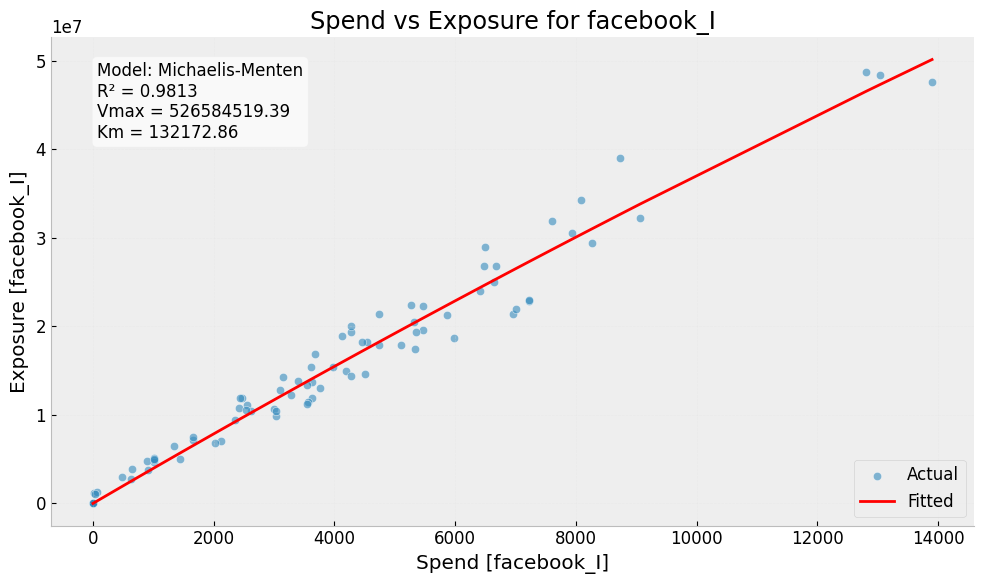

2025-10-16 17:32:01,037 - robyn.visualization.feature_visualization - INFO - Generating spend-exposure plot for channel: search_clicks_P
2025-10-16 17:32:01,042 - robyn.visualization.feature_visualization - INFO - Found result for channel search_clicks_P
2025-10-16 17:32:01,345 - robyn.visualization.feature_visualization - INFO - Successfully generated spend-exposure plot for channel search_clicks_P


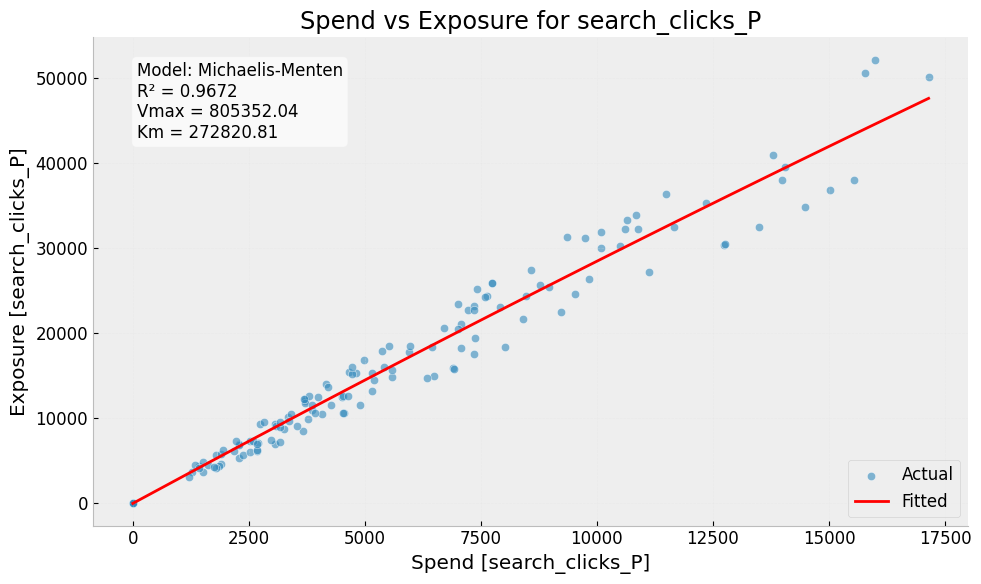

In [15]:
from robyn.visualization.feature_visualization import FeaturePlotter
# import matplotlib.pyplot as plt
%matplotlib inline

# Create plotter instance
feature_plotter = FeaturePlotter(mmm_data, hyperparameters, featurized_mmm_data)
results_list = featurized_mmm_data.modNLS["results"]

# Plot each channel
for result in results_list:
    channel = result["channel"]
    try:
        # Get the figure dictionary
        fig_dict = feature_plotter.plot_spend_exposure(channel)

        if "spend-exposure" in fig_dict:
            fig = fig_dict["spend-exposure"]
            # Need to get the axis from the figure
            ax = fig.get_axes()[0]
            # Draw the figure to make sure it's rendered
            fig.canvas.draw()
            # Display using display instead of show
            from IPython.display import display
            display(fig)

    except ValueError as e:
        print(f"Skipping {channel}: {str(e)}")
    except Exception as e:
        print(f"Error plotting {channel}: {str(e)}")

# 6. Model Training

### Training Configuration:
- `trials`: Number of parallel optimization trials (e.g., 5)
- `iterations`: Optimization iterations per trial (e.g., 2000)
- `ts_validation`: Whether to use time-series validation
- `cores`: Number of CPU cores to use for parallel processing
- `nevergrad_algo`: Optimization algorithm (TWO_POINTS_DE recommended)
- `model_name`: Model type (RIDGE regression recommended)

Parameters:
- `add_penalty_factor`: Additional regularization for stability
- `rssd_zero_penalty`: Penalize unrealistic zero contributions
- `intercept`: Include intercept term
- `intercept_sign`: Control intercept direction

Note: More iterations and trials generally lead to better results but increase computation time.

In [62]:
plt.ioff()
model_executor = ModelExecutor(
    mmmdata=mmm_data,
    holidays_data=holidays_data,
    hyperparameters=hyperparameters,
    calibration_input=None,
    featurized_mmm_data=featurized_mmm_data,
)

trials_config = TrialsConfig(iterations=2000, trials=5)

output_models = model_executor.model_run(
    trials_config=trials_config,
    ts_validation=True,
    add_penalty_factor=False,
    rssd_zero_penalty=True,
    nevergrad_algo=NevergradAlgorithm.TWO_POINTS_DE,
    intercept=True,
    intercept_sign="non_negative",
    model_name=Models.RIDGE,
)
plt.close()

2025-10-16 18:59:43,691 - robyn.modeling.base_model_executor - INFO - Initializing BaseModelExecutor
2025-10-16 18:59:43,692 - robyn.modeling.model_executor - INFO - Starting model execution with model_name=Models.RIDGE
2025-10-16 18:59:43,693 - robyn.modeling.base_model_executor - INFO - Input validation successful
2025-10-16 18:59:43,693 - robyn.modeling.base_model_executor - INFO - Preparing hyperparameters
2025-10-16 18:59:43,694 - robyn.modeling.base_model_executor - INFO - Completed hyperparameter preparation with 20 parameters to optimize
2025-10-16 18:59:43,694 - robyn.modeling.model_executor - INFO - Initializing Ridge model builder
2025-10-16 18:59:43,701 - robyn.modeling.model_executor - INFO - Building models with configured parameters
2025-10-16 18:59:43,701 - robyn.modeling.ridge.ridge_data_builder - INFO - Collecting hyperparameters for optimization...
Running trial 1 of 5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████

## 6.1. Model Convergence Analysis

After training the models, we can examine two key visualization plots that help assess model convergence and optimization quality:

### MOO Cloud Plot
This plot shows the distribution of model solutions in the objective space:
- X-axis: Model fit error (NRMSE) - lower is better
- Y-axis: Decomposition error - lower is better


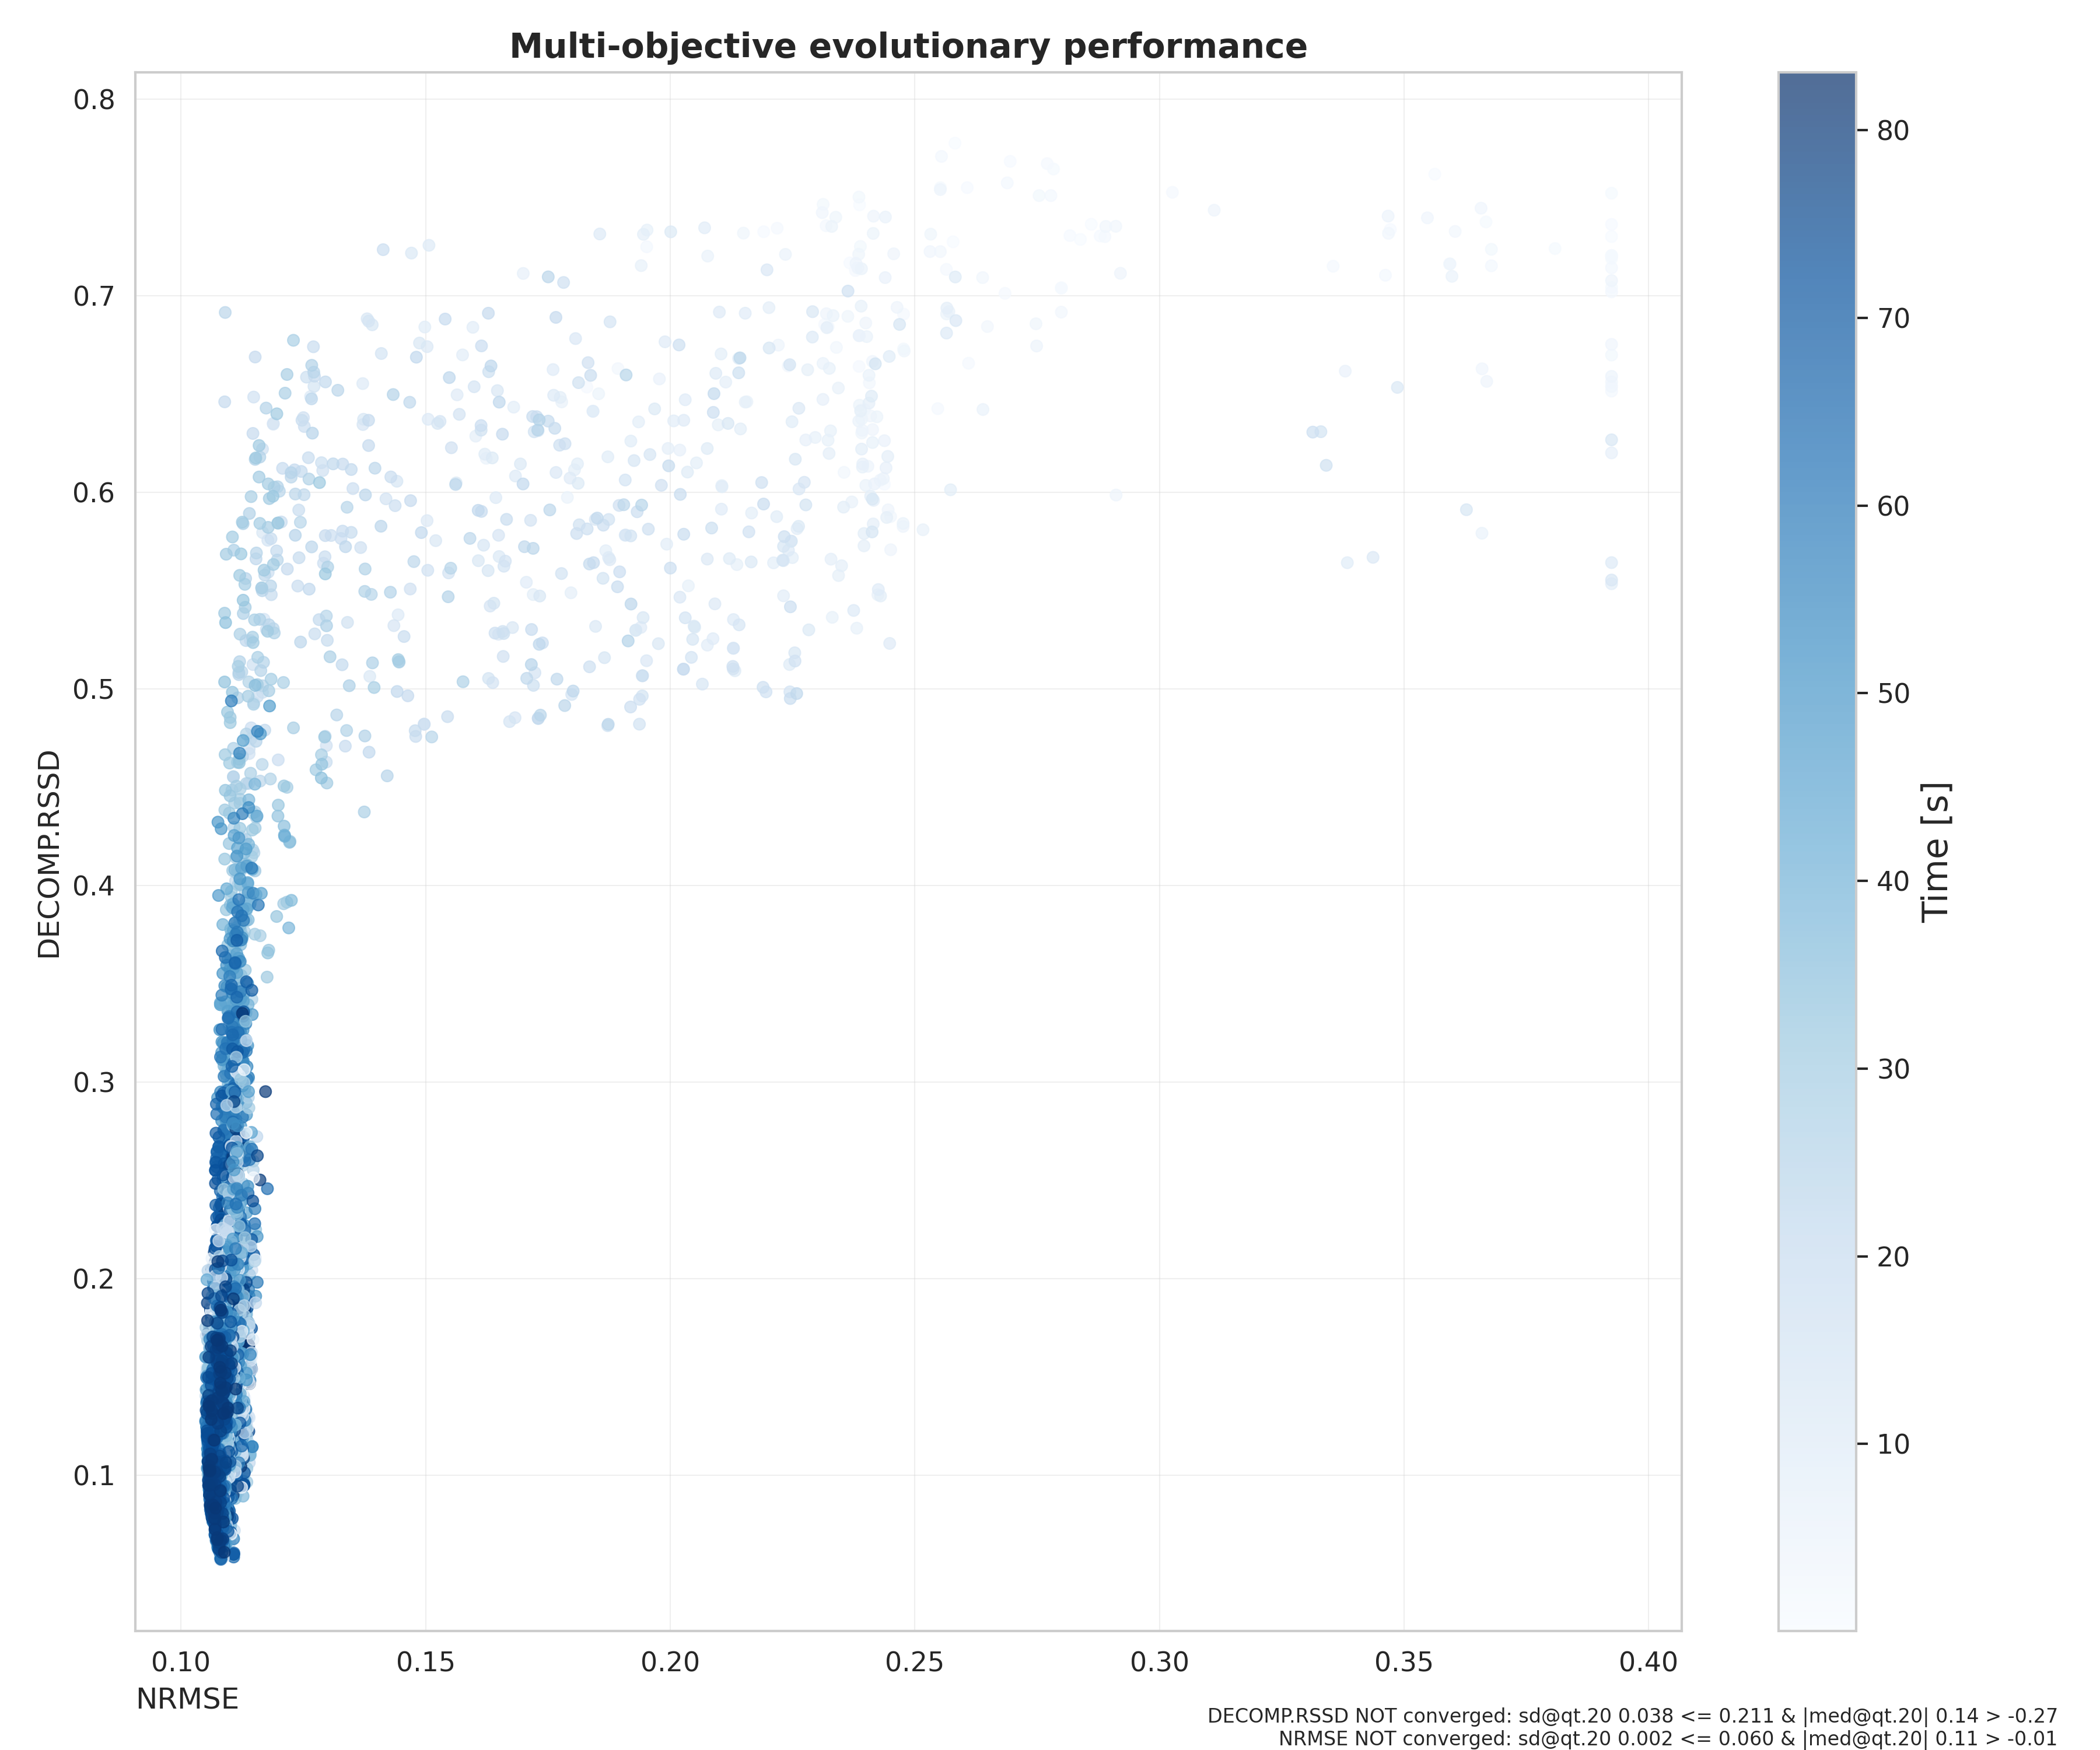

In [90]:
from IPython.display import Image, display
import base64

# Display the MOO Cloud Plot
if "moo_cloud_plot" in output_models.convergence:
    moo_cloud_plot = output_models.convergence["moo_cloud_plot"]
    display(Image(data=base64.b64decode(moo_cloud_plot)))

### MOO Distribution Plot 
This plot shows the distribution of objective values across all trials:
- Shows the spread of NRMSE and decomposition errors
- Helps identify if optimization has converged to stable solutions
- Wide distributions may indicate need for more iterations
- Narrow distributions suggest consistent model performance

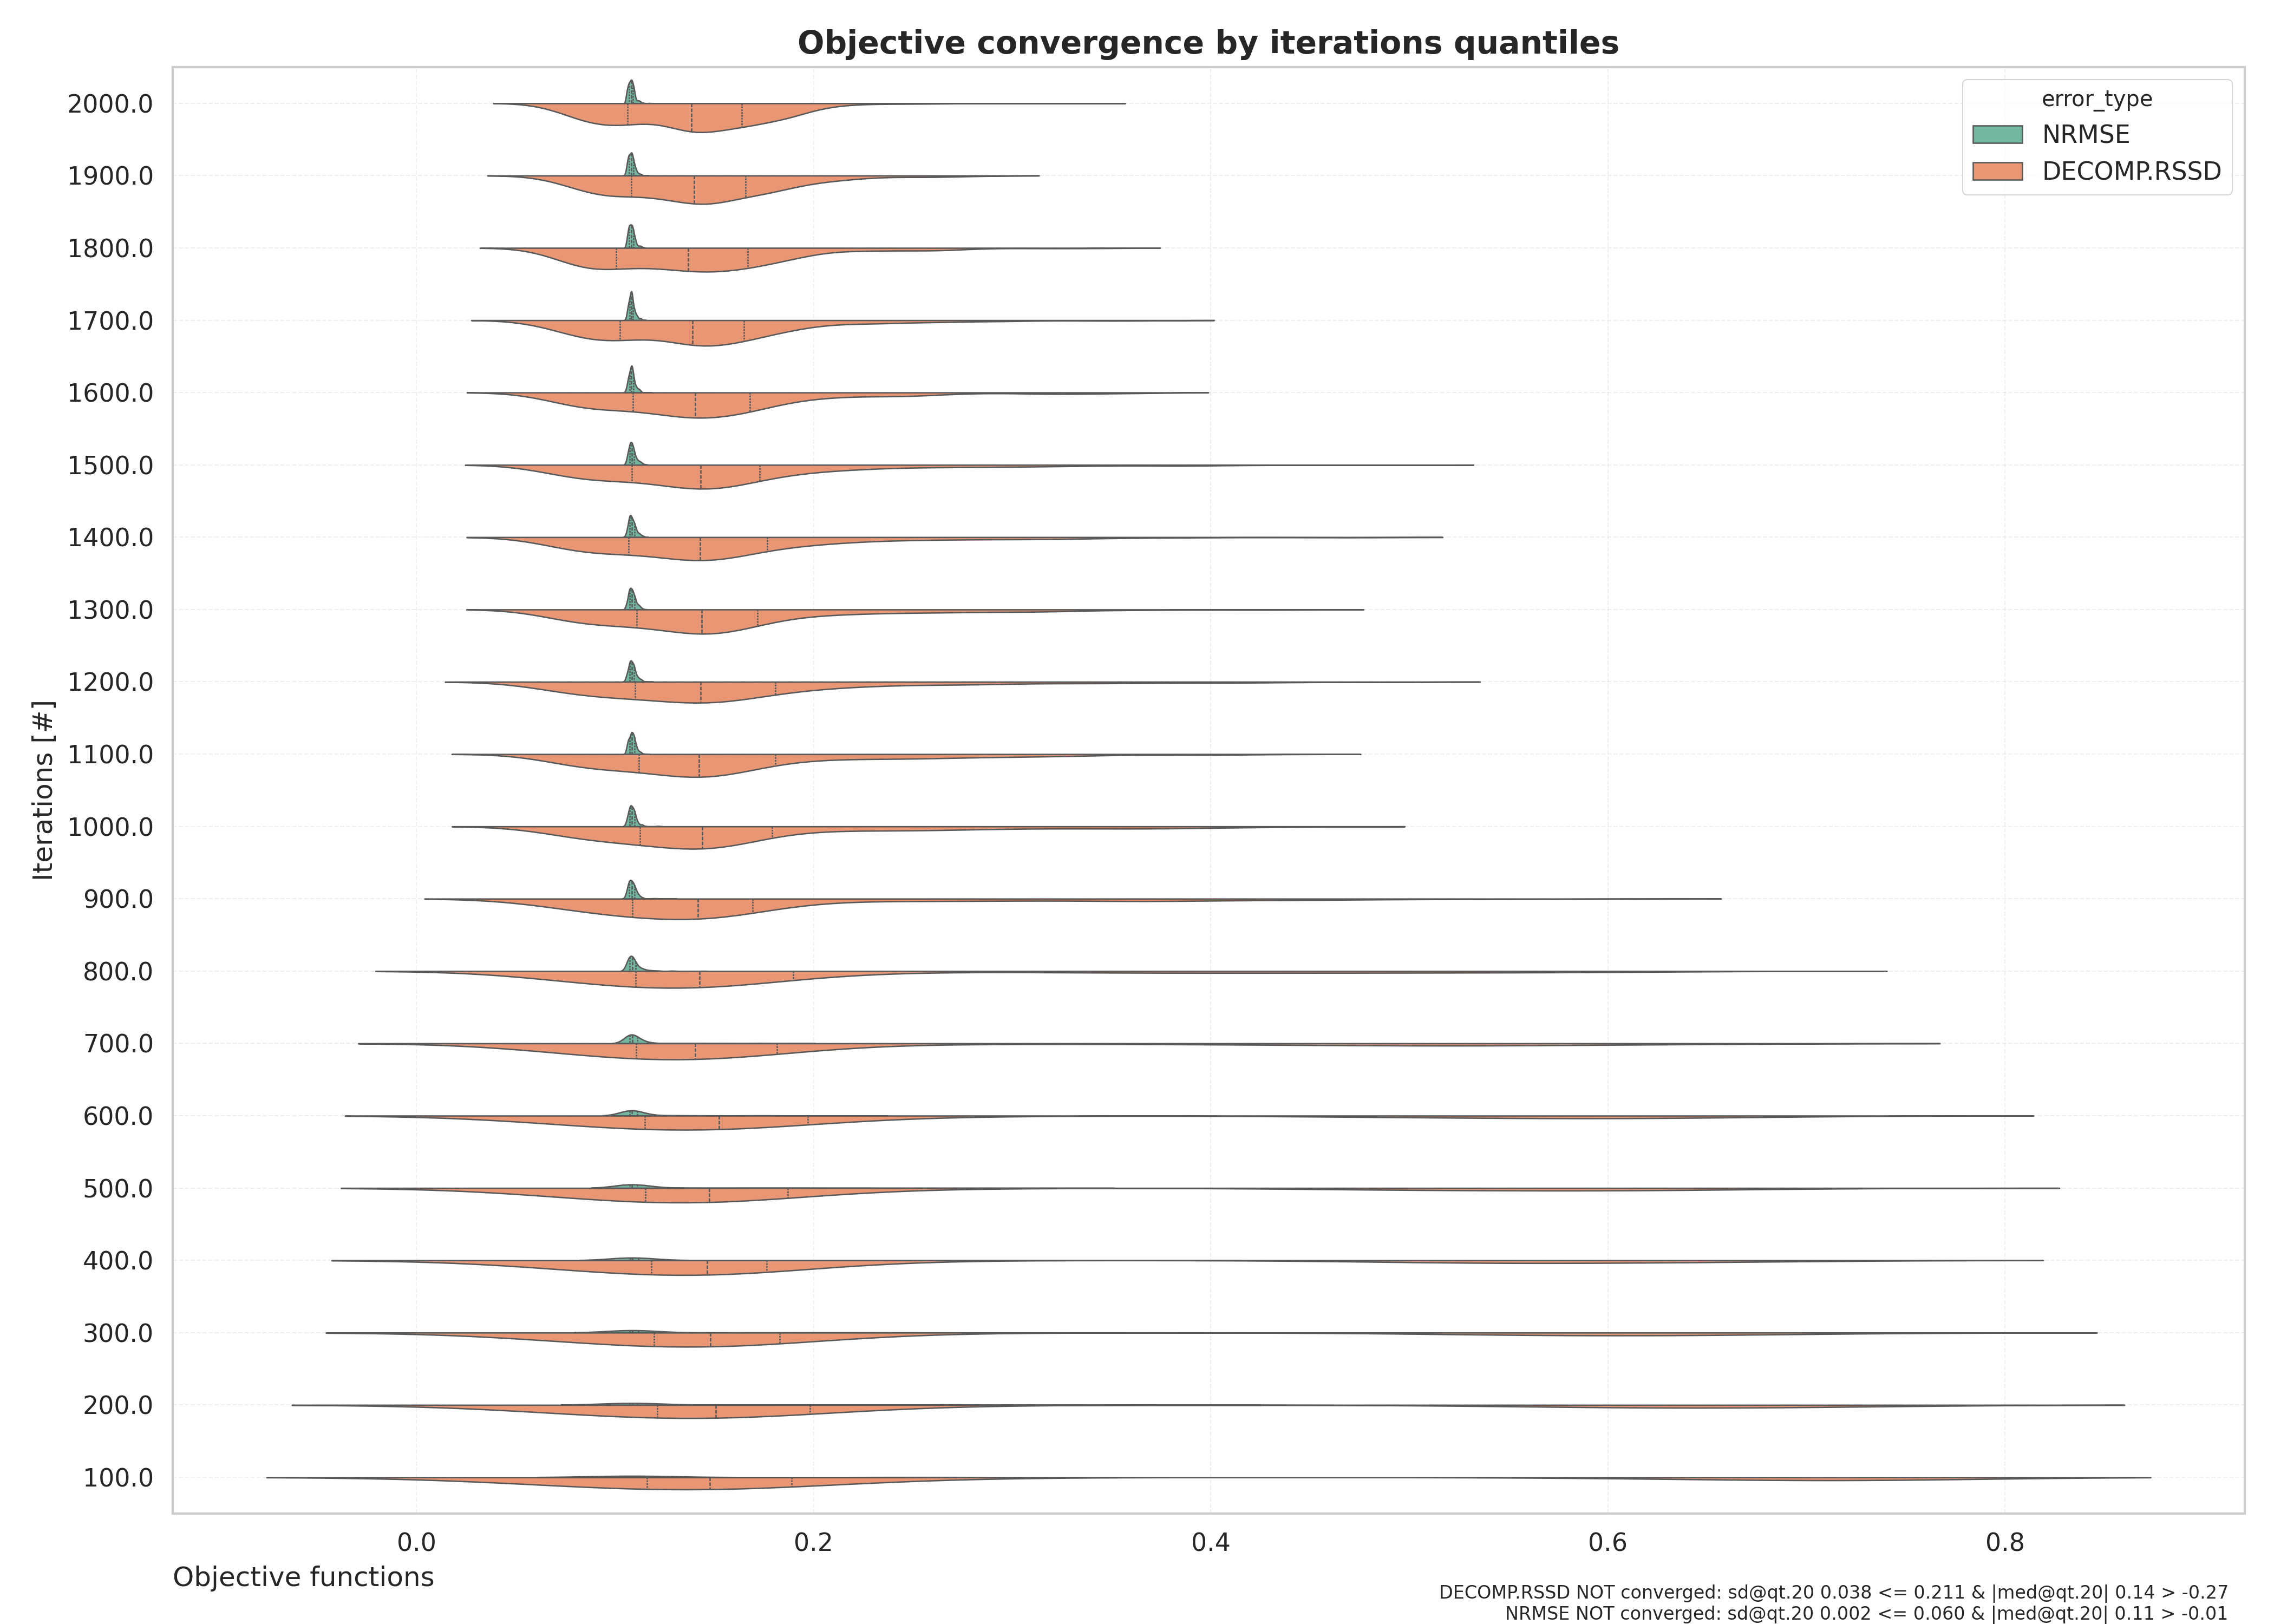

In [91]:
# Display the MOO Distribution Plot
if "moo_distrb_plot" in output_models.convergence:
    moo_distrb_plot = output_models.convergence["moo_distrb_plot"]
    display(Image(data=base64.b64decode(moo_distrb_plot)))

# 7. Model Selection and Clustering

**1. Pareto Optimization**

Pareto optimization helps select the best models by balancing multiple objectives:
- Model accuracy (NRMSE)
- Decomposition accuracy
- Model robustness

Parameters:
- `pareto_fronts`: Number of Pareto fronts to consider ("auto" recommended)
- `min_candidates`: Minimum number of models to retain (e.g., 100)

**2. Model Clustering**

Clustering groups similar models together to identify stable solutions.

Configuration parameters:
- `dep_var_type`: Type of dependent variable (revenue/conversion)
- `cluster_by`: Clustering criterion (HYPERPARAMETERS recommended)
- `max_clusters`: Maximum number of clusters to consider
- `min_clusters`: Minimum number of clusters
- `weights`: Importance weights for clustering criteria

In [92]:
from robyn.modeling.pareto.pareto_optimizer import ParetoOptimizer

# 3. Create ParetoOptimizer instance
pareto_optimizer = ParetoOptimizer(
    mmm_data, output_models, hyperparameters, featurized_mmm_data, holidays_data
)

# 4. Run optimize function
pareto_result = pareto_optimizer.optimize(pareto_fronts="auto", min_candidates=100)

2025-10-16 19:36:13 [INFO] Starting Pareto optimization
2025-10-16 19:36:13,835 - robyn.modeling.pareto.data_aggregator - INFO - Starting model data aggregation
2025-10-16 19:36:13 [INFO] Computing Pareto fronts
2025-10-16 19:36:14 [INFO] Pareto front computation completed
2025-10-16 19:36:14 [INFO] Preparing Pareto data
2025-10-16 19:36:14 [INFO] Number of Pareto-optimal solutions found: 8778
2025-10-16 19:36:14 [INFO] Selected 3 Pareto-fronts containing 152 candidates
2025-10-16 19:36:14 [INFO] Selected Pareto fronts: 4
2025-10-16 19:36:14 [INFO] Filtering data for selected Pareto fronts...
2025-10-16 19:36:14 [INFO] Pareto data preparation completed
2025-10-16 19:36:14,875 - robyn.modeling.pareto.response_curve - INFO - Calculating response curves for 760 models' media variables...
Processing rows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [93]:
cluster_configs = ClusteringConfig(
    dep_var_type=DependentVarType(mmm_data.mmmdata_spec.dep_var_type),
    cluster_by=ClusterBy.HYPERPARAMETERS,
    max_clusters=10,
    min_clusters=3,
    weights=[1.0, 1.0, 1.0],
)

cluster_builder = ClusterBuilder(pareto_result=pareto_result)


cluster_results = cluster_builder.cluster_models(cluster_configs)

2025-10-16 19:36:58,161 - robyn.modeling.clustering.cluster_builder - INFO - Initializing ClusterBuilder
2025-10-16 19:36:58,162 - robyn.modeling.clustering.cluster_builder - INFO - ClusterBuilder initialization complete
2025-10-16 19:36:58,162 - robyn.modeling.clustering.cluster_builder - INFO - Starting model clustering process
2025-10-16 19:36:58,171 - robyn.modeling.clustering.cluster_builder - INFO - Auto-detected media channels: ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S', 'newsletter']
2025-10-16 19:36:58,171 - robyn.modeling.clustering.cluster_builder - INFO - Clustering by: ClusterBy.HYPERPARAMETERS
2025-10-16 19:36:58,173 - robyn.modeling.clustering.cluster_builder - INFO - Starting optimal cluster selection
2025-10-16 19:36:58,174 - robyn.modeling.clustering.cluster_builder - INFO - Ignored features: nrmse_val, mape, nrmse, pareto, sol_id, nrmse_test, decomp.rssd, nrmse_train
2025-10-16 19:36:58,175 - robyn.modeling.clustering.cluster_builder - INFO - Starting WSS 

In [94]:
# Pareto Results
utils = ParetoUtils()
pareto_result = utils.process_pareto_clustered_results(
    pareto_result,
    clustered_result=cluster_results,
    ran_cluster=True,
    ran_calibration=False,
)

In [95]:
top_solutions = cluster_results.top_solutions.sol_id.tolist()
top_solutions

['5_1664_1', '5_1081_1', '5_1851_1']

In [117]:
cluster_results.top_solutions.sort_values("error_score")#.to_dict("list")

,cluster,rank,sol_id,facebook_S_alphas,facebook_S_gammas,facebook_S_thetas,newsletter_alphas,newsletter_gammas,newsletter_thetas,ooh_S_alphas,ooh_S_gammas,ooh_S_thetas,print_S_alphas,print_S_gammas,print_S_thetas,search_S_alphas,search_S_gammas,search_S_thetas,tv_S_alphas,tv_S_gammas,tv_S_thetas,nrmse,nrmse_train,nrmse_val,nrmse_test,decomp.rssd,mape,mape.qt10,n,error_score
9080,1,1.0,5_1081_1,2.992003,0.949203,0.017215,1.102317,0.998069,0.390837,0.500313,0.348616,0.394762,2.950387,0.314979,0.366256,0.718514,0.458433,0.119010,2.916362,0.612891,0.526186,0.108128,0.061144,0.108128,0.051477,0.057949,0.0,True,70,0.006116
9850,2,1.0,5_1851_1,2.934542,0.987979,0.004464,1.954404,0.966000,0.399303,0.500329,0.301747,0.397044,2.971926,0.360281,0.154839,1.082211,0.322676,0.075277,2.564619,0.718076,0.493635,0.106326,0.059850,0.106326,0.054420,0.078682,0.0,True,38,0.100493
9663,0,1.0,5_1664_1,2.992133,0.984723,0.004030,2.566332,0.979986,0.392634,0.501677,0.330297,0.389707,2.969140,0.382827,0.115538,1.070738,0.378742,0.059224,2.641701,0.565374,0.446387,0.105659,0.058442,0.105659,0.056343,0.094557,0.0,True,44,0.167585


In [120]:
cluster_results

ClusteredResult(cluster_data=        sol_id  facebook_S_alphas  facebook_S_gammas  facebook_S_thetas  \
7256  4_1257_1           2.941265           0.971226           0.007790   
7333  4_1334_1           2.990812           0.975090           0.006102   
7390  4_1391_1           2.991629           0.968537           0.016630   
7540  4_1541_1           2.991629           0.968537           0.016630   
7552  4_1553_1           2.881586           0.973629           0.010652   
...        ...                ...                ...                ...   
9930  5_1931_1           2.924166           0.969651           0.009748   
9932  5_1933_1           2.936000           0.974280           0.006067   
9960  5_1961_1           2.924166           0.969651           0.009748   
9967  5_1968_1           2.906593           0.992972           0.003685   
9984  5_1985_1           2.944667           0.958934           0.012230   

      newsletter_alphas  newsletter_gammas  newsletter_thetas  ooh_S_a

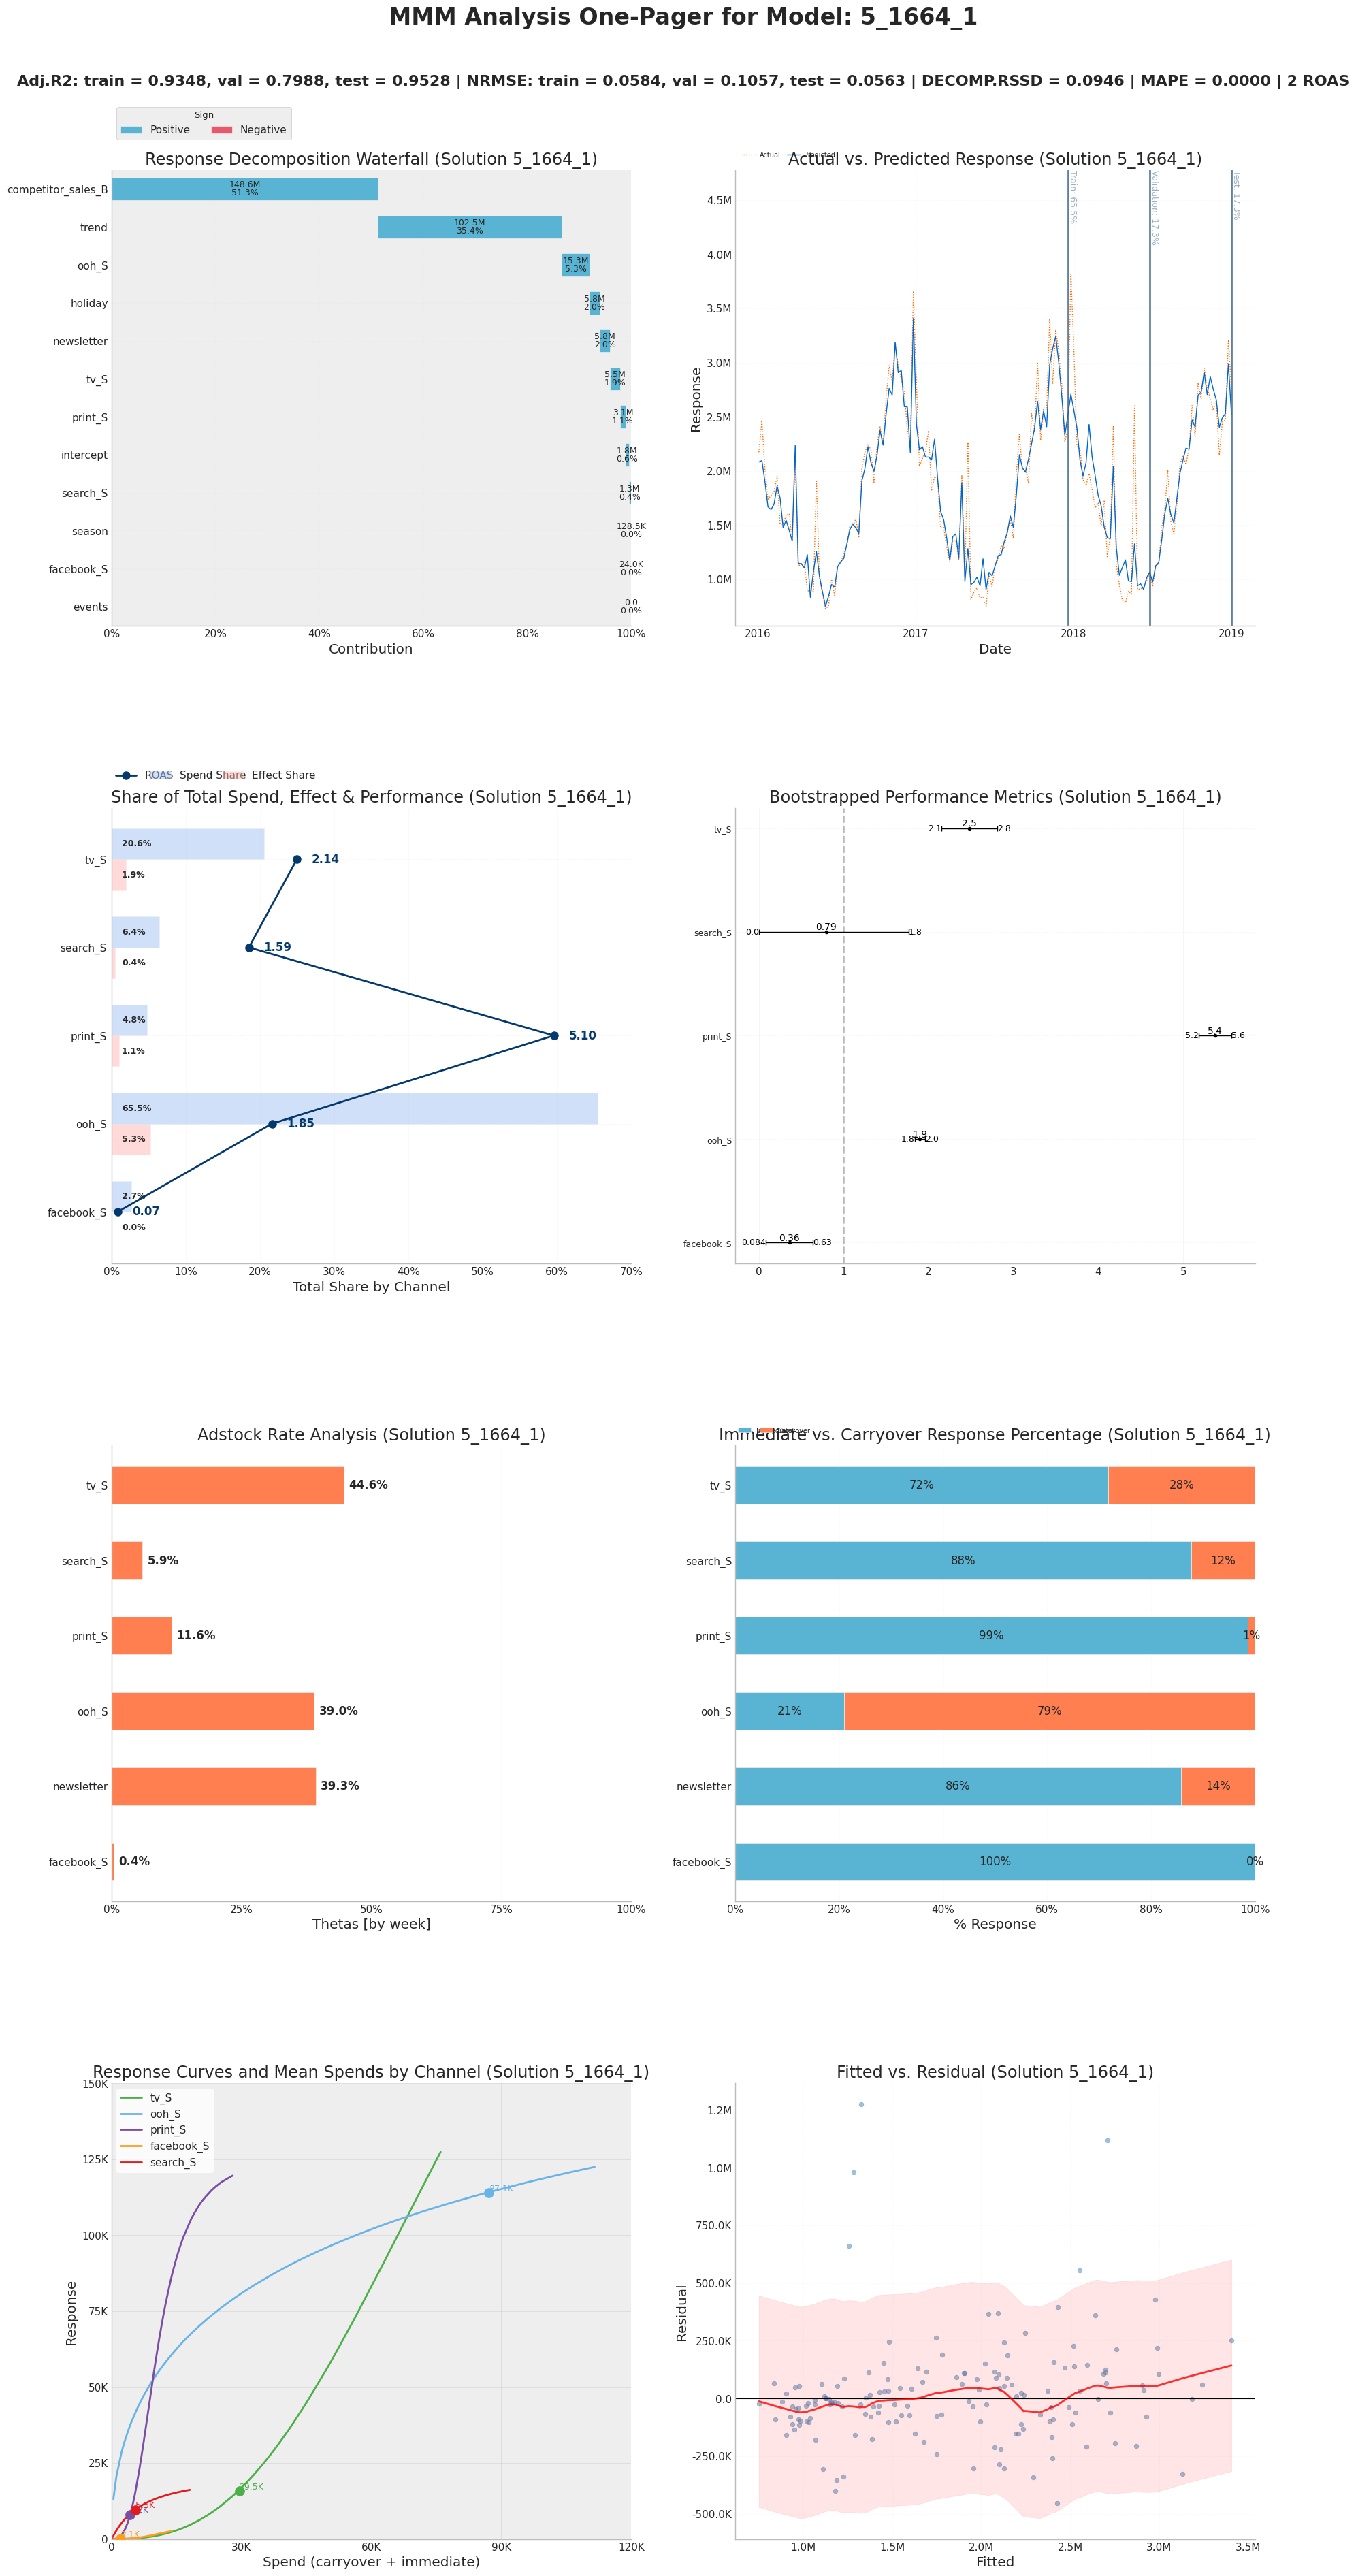

In [102]:
%matplotlib inline

from robyn.reporting.onepager_reporting import OnePager

OnePager(
    pareto_result, cluster_results, hyperparameters, mmm_data, holidays_data
).generate_one_pager(
    solution_ids=top_solutions[0],
    figsize=(20, 40),
);

# 8. Budget Allocation Optimization

Robyn provides different scenarios for budget allocation optimization. Let's explore the "max_response" scenario:

**Scenario: Maximum Response**

This scenario answers the question: "What's the maximum return given certain spend constraints?"

Key parameters:
- `total_budget`: When set to None, uses the total spend in the selected date range
- `channel_constr_low`: Minimum spend multiplier (e.g., 0.7 means channel spend can't go below 70% of current)
- `channel_constr_up`: Maximum spend multiplier per channel (e.g., 1.5 means channel spend can't exceed 150% of current)
- `channel_constr_multiplier`: Extends bounds for wider optimization insights
- `date_range`: Period for optimization ("all", "last_X", or specific date range)

Note: Other scenarios include:
- "target_efficiency": Optimize spend to hit specific ROAS or CPA targets
- "min_spend": Find minimum spend required to hit response targets
- "max_response_expected": Maximize expected response within confidence intervals

For this example, we'll demonstrate the "max_response" scenario:

In [103]:
# Create allocator parameters matching R Example 1
allocator_params = AllocatorParams(
    scenario=SCENARIO_MAX_RESPONSE,
    total_budget=None,  # When None, uses total spend in date_range
    target_value=None,
    date_range=DATE_RANGE_ALL,
    channel_constr_low=[0.7, 0.7, 0.7, 0.7, 0.7],  # One value per channel
    channel_constr_up=[1.2, 1.5, 1.5, 1.5, 1.5],  # One value per channel
    channel_constr_multiplier=DEFAULT_CONSTRAINT_MULTIPLIER,
    optim_algo=ALGO_SLSQP_AUGLAG,
    maxeval=100000,
    constr_mode=CONSTRAINT_MODE_EQ,
    plots=True,
)

# Initialize budget allocator
max_response_allocator = BudgetAllocator(
    mmm_data=mmm_data,
    featurized_mmm_data=featurized_mmm_data,
    hyperparameters=hyperparameters,
    pareto_result=pareto_result,
    select_model=top_solutions[0],
    params=allocator_params,
)

In [104]:
results_df = pd.DataFrame(
    {
        "Channel": max_response_allocator.dt_optim_out.channels,
        "Initial Spend": max_response_allocator.dt_optim_out.initSpendUnit,
        "Optimized Spend": max_response_allocator.dt_optim_out.optmSpendUnit,
        "Spend Change %": (
            max_response_allocator.dt_optim_out.optmSpendUnit
            / max_response_allocator.dt_optim_out.initSpendUnit
            - 1
        )
        * 100,
        "Initial Response": max_response_allocator.dt_optim_out.initResponseUnit,
        "Optimized Response": max_response_allocator.dt_optim_out.optmResponseUnit,
        "Response Lift %": (
            max_response_allocator.dt_optim_out.optmResponseUnit
            / max_response_allocator.dt_optim_out.initResponseUnit
            - 1
        )
        * 100,
    }
)

In [105]:
results_df.round(2)

,Channel,Initial Spend,Optimized Spend,Spend Change %,Initial Response,Optimized Response,Response Lift %
facebook_S,facebook_S,2127.89,1489.52,-30.00,19.61,6.80,-65.34
ooh_S,ooh_S,52482.13,45323.80,-13.64,113992.26,111128.08,-2.51
print_S,print_S,3832.07,5748.10,50.00,8172.98,21422.36,162.11
search_S,search_S,5158.98,7738.47,50.00,9630.79,11886.32,23.42
tv_S,tv_S,16505.81,19806.97,20.00,15578.70,20383.81,30.84


## 8.1. Budget Allocation Visualization Results

The allocator generates two key plots to visualize optimization results:

**1. Budget Comparison Plot (`_plot_budget_comparison`)**

This plot shows a comparison between three scenarios: Initial, Bounded, and Bounded x3:
- Bar pairs showing total spend vs total response for each scenario
- Each scenario includes metrics text showing:
  - For Initial: Spend, Response, and ROAS/CPA
  - For others: Percent changes in Spend and Response, plus ROAS/CPA
- Color-coded bars (Silver for Initial, Steel Blue for Bounded, Golden Rod for Bounded x3)
- Values scaled up to represent the full analysis period

**2. Allocation Matrix Plot (`_plot_allocation_matrix`)**

Shows three side-by-side heatmaps comparing allocation strategies:
- Columns in each heatmap represent:
  - Absolute mean spend (in thousands)
  - Mean spend percentage
  - Mean response percentage
  - Mean ROAS/CPA
  - Marginal ROAS/CPA
- Each row represents a different paid media channel
- Color intensity indicates relative values within each scenario
- Different color schemes for each scenario:
  - Initial: Grey scale
  - Bounded: Blue scale
  - Bounded x3: Yellow/Gold scale

2025-10-16 19:38:45,344 - robyn.visualization.allocator_visualizer - INFO - Initializing AllocatorPlotter


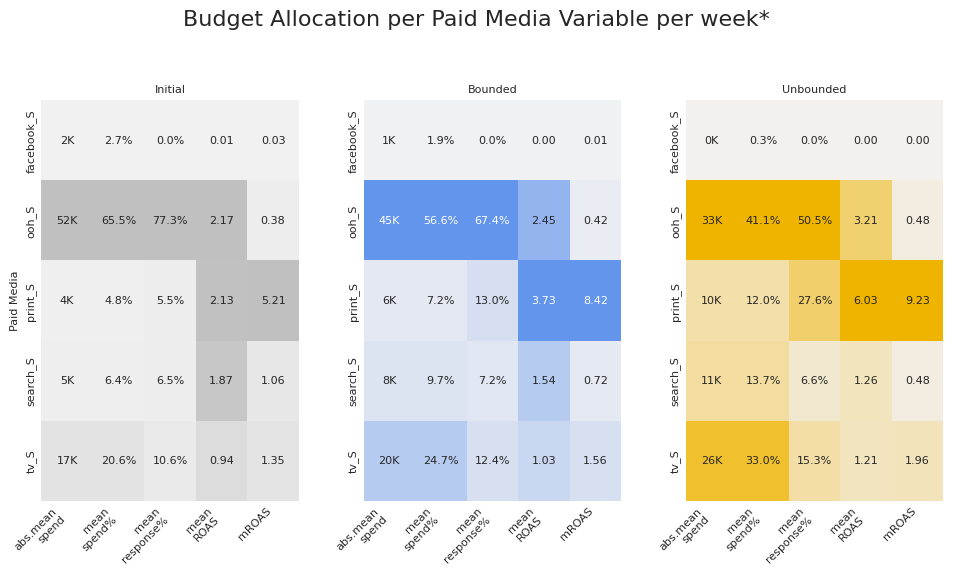

In [106]:
pio.renderers.default = "notebook"

plotter = AllocatorVisualizer(budget_allocator=max_response_allocator)
plots = plotter.plot_all(display_plots=True, export_location=None)